# COGS 108 - EDA Checkpoint

## Authors

- Jason Oh: Conceptualization, Background research, Data curation, Writing – original draft
- Luca Georgescu: Analysis, Methodology, Software, Visualization, Data Wrangling
- Brendan Keane: Project administration, Analysis, Writing – review & editing, Visualization


# Research Question

To what extent do advanced college basketball efficiency metrics and player characteristics predict whether a player is selected in the NBA Draft?

The basketball efficiency metrics we are focusing on are:
- True Shooting Percentage (TS%)
- Box Plus Minus(BPM)

The player characteristics we are focusing on are:
- College Conference Affiliation
- College year

Draft selection will be operationalized as a binary outcome variable (1 = drafted, 0 = not drafted).



## Background and Prior Work


The NBA Draft is one of the most important mechanisms through which teams acquire young talent, yet predicting which college basketball players will succeed at the professional level remains extremely difficult. Despite teams having access to extensive scouting resources and increasingly detailed performance data, draft outcomes often fail to align with future NBA productivity. This uncertainty has motivated researchers to examine whether measurable college basketball statistics can meaningfully explain if a player is drafted, their downstream success, and whether decision makers systematically rely on the “right” information when making draft selections.

Prior research by Sailofsky (2018) examined NCAA Division I basketball statistics and pre-draft player characteristics to determine which factors predict NBA draft position and future NBA performance.<sup><a href="#ref1">1</a></sup> Using regression models on players drafted between 2006 and 2013, the study found that NBA teams tend to emphasize variables such as scoring totals, size, and college conference affiliation, even though these factors do not strongly predict NBA success. Instead, the paper highlights offensive efficiency, ball control, and rebounding efficiency as more reliable indicators of professional performance. This work suggests that draft decisions are often influenced by cognitive biases and overconfidence, leading teams to prioritize visible or traditional metrics rather than those most closely tied to winning.

Similarily, the article How NBA Teams Use Advanced Stats to Draft Smarter<sup><a href="#ref2">2</a></sup> examines how modern NBA front offices integrate advanced analytics into draft strategy to reduce risk and improve talent evaluation. It explains how teams use predictive modeling built on metrics such as Player Efficiency Rating (PER), Box Plus-Minus (BPM), True Shooting Percentage (TS%), and Win Shares (WS) to project how college and international prospects will translate to the NBA, adjusting for pace, role, and competition level. The article also highlights the growing role of biomechanical analytics, wearable sensors, and motion capture technology in forecasting injury risk, as well as real-time player tracking systems like SportVU and Second Spectrum that capture spatial and decision-making data beyond the box score. Ultimately, the piece emphasizes that while advanced statistics have transformed roster-building by enabling more data-driven projections, the most effective draft strategies blend analytics with traditional scouting to account for intangibles such as character, leadership, and coachability.

In The Life of an Independent NBA Draft Analyst: Behind the Scouting Lens<sup><a href="#ref3">3</a></sup>, Rafael Barlowe provides a firsthand account of the realities of independent NBA draft scouting, highlighting the balance between in-person evaluation, film study, and navigating the politics of draft intel. He describes the unpredictability of prospect evaluation and the limitations of relying solely on game film, emphasizing that live scouting reveals nuances such as demeanor, communication, and competitiveness that statistics cannot capture. Barlowe outlines a rigorous evaluation process that combines full-game film breakdowns, advanced analytics, role projection, and possession-level review to assess how prospects might function within NBA ecosystems. He also reflects on the importance of trusting independent judgment over consensus, learning from scouting misses, and accounting for off-court factors such as maturity, cultural adjustment, and support systems. This source helped us understand the limitations of our desired project, since it is nearly impossible to model qualitative factors such as effort and maturity, which will lead to a characteristic gap in our eventual analysis.

Building on this prior work, our project focuses specifically on examining the statistical relationships between college basketball performance metrics and NBA draft outcomes for players eligible for the NBA Draft. Our analysis aims to identify patterns and associations in the data, contributing to existing research on draft decision-making and highlighting which types of college-level statistics appear most closely linked to draft selection.

References

1. <a name="ref1"></a>
Sailofsky, D. (2018). Drafting Errors and Decision Making Theory in the NBA Draft. Brock University Master’s Thesis. https://brocku.scholaris.ca/server/api/core/bitstreams/9940fb5f-cdb8-4b32-afd9-09810ea41dbd/content
<a href="#top">^</a>

2. <a name="ref2"></a>
How NBA Teams Use Advanced Stats to Draft Smarter. NBAstuffer. https://www.nbastuffer.com/how-nba-teams-use-analytics-to-draft/
<a href="#top">^</a>

3. <a name="ref3"></a>
Barlowe, R. (2024) NBA Big Board. “The Life of an Independent NBA Draft Analyst: Behind the Scouting Lens”
https://www.nbabigboard.com/p/the-life-of-an-independent-nba-draft
<a href="#top">^</a>


# Hypothesis


We hypothesize that higher True Shooting Percentage (TS%, defined as a player’s scoring efficiency accounting for field goals, three-pointers, and free throws) and BPM (Box Plus Minus) values are positively associated with NBA draft selection. Specifically, we expect that players with higher efficiency and overall impact metrics will have a greater probability of being drafted (Drafted = 1).

We believe TS% and BPM are particularly important because they capture overall scoring efficiency and a player’s total on-court impact, rather than raw scoring volume alone. Unlike traditional statistics that reflect usage or opportunity, efficiency-based metrics better account for shot quality, decision-making, and two-way contribution, which may be more indicative of NBA-ready performance. Additionally, we expect player characteristics such as position, and participation in higher-profile conferences to be positively associated with draft selection.

## Data

### Data overview

- Dataset Name: College Basketball Players 2009 – 2021
- Link to the dataset: https://www.kaggle.com/datasets/adityak2003/college-basketball-players-20092021
- Number of observations: The dataset contains 61,061 player-season observations from NCAA Division I men’s basketball between 2009 and 2021. Each row represents one player in one season.
- Number of variables: 65
- Variables most relevant to this project:
  - True Shooting Percentage (TS%): A scoring efficiency metric that accounts for field goals, three-point shots, and free throws. It is expressed as a proportion (typically between 0 and 1). Higher values indicate more efficient scoring performance.
  - Box Plus-Minus (BPM): An advanced metric estimating a player's overall contribution per 100 possessions relative to an average player. A value of 0 represents average impact, positive values indicate above-average performance, and negative values indicate below-average impact.
  - College Conference Affiliation: A categorical variable identifying the NCAA conference in which the player competed (e.g., ACC, SEC, Big Ten). Conference strength may influence visibility, level of competition, and draft exposure.
  - College Year (Class Year): A categorical variable indicating the player’s academic/eligibility year (Freshman, Sophomore, Junior, Senior). Underclassmen may have different draft probabilities due to perceived long-term potential.

- Description of shortcomings this dataset has with respect to the project:
  - The dataset is observational and does not include qualitative scouting information such as injury history, leadership ability, or work ethic, which may influence draft decisions.
  - Players appear multiple times across seasons, requiring us to restrict the analysis to each player’s final collegiate season to ensure independence.
  - Advanced metrics such as BPM or TS% may have missing values in some seasons, particularly in earlier years.
  - Draft outcomes are not included in this dataset and must be merged from a separate draft dataset.

In [1]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [15]:
# Setup code -- this only needs to be run once after cloning the repo!
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
# %pip install requests tqdm

import sys
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data

# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries; 
# each dict has keys of 
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored 
datafiles = [
    { 'url': 'https://raw.githubusercontent.com/COGS108/Group044_WI26/refs/heads/master/data/00-raw/player_stats.csv', 'filename':'player_stats.csv'}
]

get_data.get_raw(datafiles,destination_directory='data/00-raw/')

Overall Download Progress: 100%|██████████| 1/1 [00:25<00:00, 25.75s/it]

Successfully downloaded: player_stats.csv


### NCAA Division I Men's Basketball Player Dataset (2009-2021) #1 

#### Detailed Description of Dataset #1: College Basketball Players 2009–2021

The College Basketball Players 2009–2021 dataset contains season-level statistics for NCAA Division I men’s basketball players across multiple seasons. Each row represents one player in one season, and the dataset includes both traditional box-score statistics and advanced efficiency metrics. Because it includes all Division I players rather than only drafted athletes, it provides a comprehensive population from which draft outcomes can later be examined.

The most important variables for this project are True Shooting Percentage (TS%), Box Plus-Minus (BPM), college conference affiliation, and college year (class year).

- True Shooting Percentage (TS%) is an advanced scoring efficiency metric expressed as a proportion between 0 and 1 (sometimes displayed as a percentage). It accounts for two-point field goals, three-point field goals, and free throws, providing a more complete measure of scoring efficiency than field goal percentage alone. In NCAA basketball, average TS% values typically fall around 0.50–0.55. Values above 0.60 indicate highly efficient scoring, while values below 0.45 suggest poor efficiency. Because TS% adjusts for shot value and free-throw attempts, it better reflects shot selection and scoring effectiveness.

- Box Plus-Minus (BPM) is an advanced metric measured in estimated points per 100 possessions relative to an average NCAA player. A BPM of 0 represents average impact. Positive values indicate above-average overall contribution, while negative values indicate below-average impact. For example, a BPM of +5 suggests a strong impact player who significantly improves team performance, while a BPM of −3 indicates below-average contribution. BPM attempts to summarize a player’s total offensive and defensive impact using box-score statistics, making it useful for evaluating overall effectiveness rather than scoring volume alone.

- College Conference Affiliation is a categorical variable identifying the NCAA conference in which the player competed (e.g., ACC, SEC, Big Ten). Conference membership is not measured in numeric units but represents structural context. Players in higher-profile conferences may face stronger competition and receive greater national exposure, potentially influencing draft outcomes.

- College Year (Class Year) is a categorical variable (Freshman, Sophomore, Junior, Senior) representing a player’s eligibility level. This variable captures experience and development stage. Underclassmen (especially freshmen) may be drafted based on projected potential, while seniors may be evaluated differently due to age and perceived development ceiling.


#### Major Concerns and Limitations of the Dataset

Although this dataset is large and comprehensive, several concerns are relevant to this project:

First, the dataset is observational and purely quantitative. It does not include qualitative scouting evaluations such as leadership, defensive communication, athletic testing results, injury history, or personality assessments. NBA draft decisions rely heavily on these qualitative factors, meaning statistical performance alone may not fully explain draft outcomes.

Second, the dataset includes repeated observations for players across multiple seasons. Without proper filtering, this could violate independence assumptions. To address this, we will restrict the analysis to each player’s final collegiate season prior to draft eligibility.

Third, advanced metrics such as TS% and BPM may have missing values in certain seasons, particularly in earlier years where advanced tracking was less consistent. Missing data may not be random; for example, players with limited minutes may lack sufficient possessions for advanced metrics to be computed reliably.

Fourth, college performance statistics are influenced by team system, pace of play, coaching strategy, and conference strength. As a result, efficiency metrics may partially reflect contextual factors rather than pure individual ability.

Finally, because the dataset includes all Division I players, there may be substantial variability in playing time. Players with very limited minutes may exhibit extreme TS% or BPM values due to small sample sizes, which could create statistical outliers that require careful handling. Using the IQR method we decided on setting upper and lower fences for TS% and BPM in order to filter out any outliers. 



Tidyness Check:

Head of raw dataset:


,player_name,team,conf,GP,Min_per,Ortg,usg,eFG,TS_per,ORB_per,...,dgbpm,oreb,dreb,treb,ast,stl,blk,pts,Unnamed: 64,Unnamed: 65
0,DeAndrae Ross,South Alabama,SB,26,29.5,97.3,16.6,42.5,44.43,1.6,...,-1.941150,0.1923,0.6154,0.8077,1.1923,0.3462,0.0385,3.8846,NaN,6.22026
1,Pooh Williams,Utah St.,WAC,34,60.9,108.3,14.9,52.4,54.48,3.8,...,-0.247934,0.6765,1.2647,1.9412,1.8235,0.4118,0.2353,5.9412,NaN,3.94375
2,Jesus Verdejo,South Florida,BE,27,72.0,96.2,21.8,45.7,47.98,2.1,...,-0.883163,0.6296,2.3333,2.9630,1.9630,0.4815,0.0000,12.1852,NaN,10.92680
3,Mike Hornbuckle,Pepperdine,WCC,30,44.5,97.7,16.0,53.6,53.69,4.1,...,-0.393459,0.7000,1.4333,2.1333,1.1000,0.5667,0.1333,4.9333,NaN,6.77427
4,Anthony Brown,Pacific,BW,33,56.2,96.5,22.0,52.8,54.31,8.3,...,-0.668318,1.4242,3.3030,4.7273,0.8485,0.4545,0.3333,7.5758,NaN,0.00000


Shape of raw dataset: (61061, 66)
Columns of raw dataset: Index(['player_name', 'team', 'conf', 'GP', 'Min_per', 'Ortg', 'usg', 'eFG',
       'TS_per', 'ORB_per', 'DRB_per', 'AST_per', 'TO_per', 'FTM', 'FTA',
       'FT_per', 'twoPM', 'twoPA', 'twoP_per', 'TPM', 'TPA', 'TP_per',
       'blk_per', 'stl_per', 'ftr', 'yr', 'ht', 'num', 'porpag', 'adjoe',
       'pfr', 'year', 'pid', 'type', 'Rec Rank', 'ast/tov', 'rimmade',
       'rimmade+rimmiss', 'midmade', 'midmade+midmiss',
       'rimmade/(rimmade+rimmiss)', 'midmade/(midmade+midmiss)', 'dunksmade',
       'dunksmiss+dunksmade', 'dunksmade/(dunksmade+dunksmiss)', 'pick',
       'drtg', 'adrtg', 'dporpag', 'stops', 'bpm', 'obpm', 'dbpm', 'gbpm',
       'mp', 'ogbpm', 'dgbpm', 'oreb', 'dreb', 'treb', 'ast', 'stl', 'blk',
       'pts', 'Unnamed: 64', 'Unnamed: 65'],
      dtype='object')
Missingness across full dataset: 209597

From this we can see that the raw dataset is overall tidy, especially regarding our columns of interest

Size

,player_name,conf,TS_per,yr,bpm,drafted
0,DeAndrae Ross,SB,44.43,So,-4.995140,0
1,Pooh Williams,WAC,54.48,So,0.593024,0
2,Jesus Verdejo,BE,47.98,Sr,0.003161,0
3,Mike Hornbuckle,WCC,53.69,Sr,-0.977798,0
4,Anthony Brown,BW,54.31,Sr,-1.836060,0


Missingness Analysis

Total amount of missing data: 339
Missing data per column: 


yr             294
bpm             45
player_name      0
conf             0
TS_per           0
drafted          0
dtype: int64

The year column has the most missing data, so let's investigate if it is missing at random or missing systematically:


,TS_per,bpm,drafted
yr_missing,,,
0,47.698807,-2.509232,0.023615
1,23.898605,-9.632279,0.000000


All the numerical columns have pretty different average values depending on the missingness of year
We believe that this is due to the small number of missing values compared to the large number of non-missing values
So we conclude that the missingness of year is most likely random

To deal with this missingness we will drop rows which have any missing values across its columns
We chose the any method because many columns do not have any missing values
Outlier Analysis

The only columns which could have outliers are the numerical columns: TS_per & bpm
Let's plot histograms of each variable so we can visualize any outliers

TS Per & BPM Histograms are at the bottom of the output


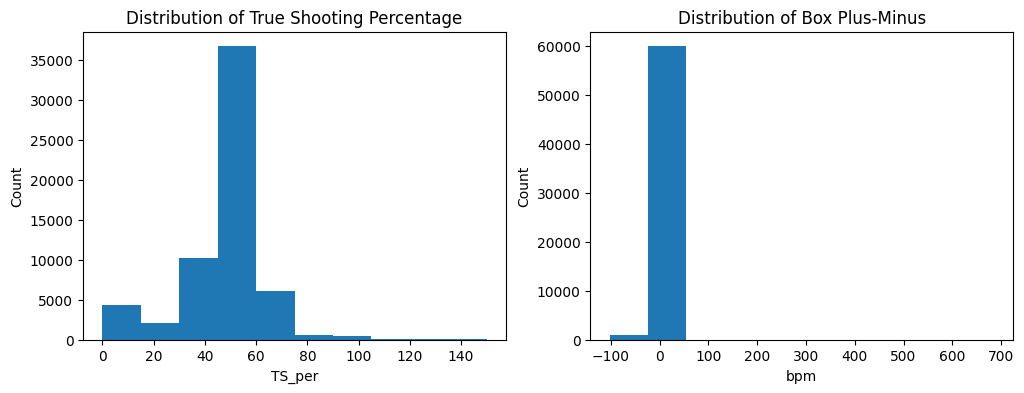

As we can see, TS_per and bpm both seem to have outliers
Now we will identify the outliers using the IQR method

Number of True Shooting Percentage outliers: 7147

Number of Box Plus-Minus outliers: 2826
Final Data Cleaning

Data Cleaning Steps:
Previous steps to simplify analysis: Drop rows with any nan values, find drafted value from pick, and filter to signficiant columns
1. Drop rows with outliers in TS-per or BPM
2. Turn year column into numerical data
3. For mutli-yeared players with multiple entries, only keep last year


In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Load in data
data_path = 'data/00-raw/player_stats.csv'
raw_df = pd.read_csv(data_path)

# Show that the raw dataset is tidy
print("=======================================================================================================================")
print("Tidyness Check:\n")
print("Head of raw dataset:")
display(raw_df.head())
print(f"Shape of raw dataset: {raw_df.shape}")
print(f"Columns of raw dataset: {raw_df.columns}")
print(f"Missingness across full dataset: {raw_df.isnull().sum().sum()}")

print("\nFrom this we can see that the raw dataset is overall tidy, especially regarding our columns of interest\n")
print("=======================================================================================================================")

print("Size of the dataset:")
print(f"Rows: {raw_df.shape[0]}")
print(f"Columns: {raw_df.shape[1]}")

# Choose significant columns that we will focus on for the rest of the dataset analysis
cleaned_df = raw_df[['player_name', 'conf', 'TS_per', 'yr', 'pick', 'bpm']].copy()

# Create drafted column which contains 1 if player was drafted and 0 if not
# Draft status is determined from whether pick has a nan value or not
# This must be done before the rest of the analysis since the nan values in this column do not represent missing data, but instead not being drafted
cleaned_df['drafted'] = cleaned_df['pick'].apply(lambda x: 0 if np.isnan(x) else 1)
cleaned_df = cleaned_df.drop(columns=['pick'])

print("\nHead of cut dataset: (After filtering only columns of interest)")
display(cleaned_df.head())
print("=======================================================================================================================")
print("Missingness Analysis\n")

print(f"Total amount of missing data: {cleaned_df.isna().sum().sum()}")
print("Missing data per column: ")
display(cleaned_df.isna().sum().sort_values(ascending=False))
print("The year column has the most missing data, so let's investigate if it is missing at random or missing systematically:")
cleaned_df["yr_missing"] = cleaned_df["yr"].isna().astype(int)
display(cleaned_df.groupby("yr_missing")[['TS_per', 'bpm', 'drafted']].mean())
print("All the numerical columns have pretty different average values depending on the missingness of year")
print("We believe that this is due to the small number of missing values compared to the large number of non-missing values")
print("So we conclude that the missingness of year is most likely random\n")



# Drop any columns which have nan values in signficant columns
# Using 'any' method since if a player has any missing data then that players overall data is unusable
print("To deal with this missingness we will drop rows which have any missing values across its columns")
print("We chose the any method because many columns do not have any missing values")
cleaned_df = cleaned_df.dropna(how='any')

print("=======================================================================================================================")
print("Outlier Analysis\n")

print("The only columns which could have outliers are the numerical columns: TS_per & bpm")
print("Let's plot histograms of each variable so we can visualize any outliers\n")
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
print("TS Per & BPM Histograms are at the bottom of the output")
cleaned_df["TS_per"].plot(kind="hist",
                          title="Distribution of True Shooting Percentage",
                          xlabel="TS_per",
                          ylabel="Count",
                          ax=ax[0])
cleaned_df["bpm"].plot(kind="hist",
                       title="Distribution of Box Plus-Minus",
                       xlabel="bpm",
                       ylabel="Count",
                       ax=ax[1])

plt.show()

print("As we can see, TS_per and bpm both seem to have outliers")
print("Now we will identify the outliers using the IQR method")

# Identify outliers from True Shooting Percentage column using IQR method
ts_Q1 = cleaned_df['TS_per'].quantile(0.25)
ts_Q3 = cleaned_df['TS_per'].quantile(0.75)
ts_IQR = ts_Q3 - ts_Q1
ts_lowerfence = ts_Q1 - 1.5 * ts_IQR
ts_upperfence = ts_Q3 + 1.5 * ts_IQR
num_ts_outliers = len(cleaned_df[(cleaned_df['TS_per'] < ts_lowerfence) | (cleaned_df['TS_per'] > ts_upperfence)])
print(f"\nNumber of True Shooting Percentage outliers: {num_ts_outliers}")

# Identify outliers in Box Plus-Minus column using IQR method
bpm_Q1 = cleaned_df['bpm'].quantile(0.25)
bpm_Q3 = cleaned_df['bpm'].quantile(0.75)
bpm_IQR = bpm_Q3 - bpm_Q1
bpm_lowerfence = bpm_Q1 - 1.5 * bpm_IQR
bpm_upperfence = bpm_Q3 + 1.5 * bpm_IQR
num_bpm_outliers = len(cleaned_df[(cleaned_df['bpm'] < bpm_lowerfence) | (cleaned_df['bpm'] > bpm_upperfence)])
print(f"\nNumber of Box Plus-Minus outliers: {num_bpm_outliers}")

print("=======================================================================================================================")
print("Final Data Cleaning\n")

print("Data Cleaning Steps:")
print("Previous steps to simplify analysis: Drop rows with any nan values, find drafted value from pick, and filter to signficiant columns")
print("1. Drop rows with outliers in TS-per or BPM")
print("2. Turn year column into numerical data")
print("3. For mutli-yeared players with multiple entries, only keep last year")


# Filter out outlier values
cleaned_df = cleaned_df[(cleaned_df['TS_per'] > ts_lowerfence) & (cleaned_df['TS_per'] < ts_upperfence)]
cleaned_df = cleaned_df[(cleaned_df['bpm'] > bpm_lowerfence) & (cleaned_df['bpm'] < bpm_upperfence)]


# Players who have played multiple years will appear multiple times so we will only keep their last season
# We keep their last seasons since it will most likely be their best season or the season they are drafted

# Helper Function
def quantify_year(yr):
    if yr == 'Fr':
        return 1
    elif yr == 'So':
        return 2
    elif yr == 'Jr':
        return 3
    elif yr == 'Sr':
        return 4
    else:
        return np.nan

cleaned_df['yr_numerical'] = cleaned_df['yr'].apply(quantify_year)
cleaned_df = cleaned_df.loc[cleaned_df.groupby("player_name")["yr_numerical"].idxmax()]
cleaned_df = cleaned_df.reset_index(drop=True).drop(columns=['yr'])

# Reorder columns
cleaned_df = cleaned_df[['player_name', 'yr_numerical', 'conf', 'TS_per', 'bpm', 'drafted']]

### Dataset #2
 as above, add any more copies of this that you need to given how many datasets you have

In [4]:
## YOUR CODE TO LOAD/CLEAN/TIDY/WRANGLE THE DATA GOES HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION 

## Results

### Exploratory Data Analysis

In this section, we conduct exploratory data analysis on the cleaned dataset of NCAA basketball player statistics to better understand the characteristics of the players included in the dataset and how these characteristics relate to NBA draft outcomes. The goal of this analysis is to identify patterns in player performance, experience, and conference representation that may help explain which factors are associated with being selected in the NBA draft.

We begin by examining the overall structure of the dataset, including the distributions of key performance metrics such as True Shooting Percentage (TS%) and Box Plus-Minus (BPM), as well as descriptive characteristics such as year in college, draft status, and conference representation. These visualizations help provide context about the composition of the dataset and highlight the selective nature of the NBA draft relative to the large number of collegiate athletes.

Next, we explore relationships between player performance metrics and draft outcomes. By comparing TS% and BPM between drafted and undrafted players, analyzing the relationship between these metrics, and examining draft rates across player experience levels and conferences, we aim to identify patterns that may indicate which types of players are more likely to be selected in the NBA draft.

Together, these exploratory analyses provide a clearer understanding of the dataset and help guide the subsequent stages of the project, where we further investigate the factors that influence NBA draft selection.




In [59]:
#Load Processed Data
datafiles = [
    { 'url': 'https://raw.githubusercontent.com/COGS108/Group044_WI26/refs/heads/master/data/02-processed/cleaned_player_stats.csv', 'filename':'cleaned_player_stats.csv'}
]

get_data.get_raw(datafiles,destination_directory='data/02-processed/')
data_path = 'data/02-processed/cleaned_player_stats.csv'
cleaned_df = pd.read_csv(data_path)


Overall Download Progress: 100%|██████████| 1/1 [00:00<00:00,  1.10it/s]

Successfully downloaded: cleaned_player_stats.csv


#### Section 1 of EDA - Dataset Characteristics and Metric Distributions

In this section, we explore several descriptive characteristics of the dataset to better understand the composition of NCAA basketball players included in the analysis. We begin by examining the distributions of key performance metrics, including Box Plus-Minus (BPM) and True Shooting Percentage (TS%), which provide insight into overall player impact and scoring efficiency across all players in the dataset. Understanding the distribution of these variables helps establish a baseline view of player performance before examining how they relate to NBA draft outcomes.

We then analyze the distribution of players by year in college and draft status to understand the experience levels of players represented in the dataset and to highlight how selective the NBA draft process is relative to the large pool of collegiate athletes.

Finally, we examine the distribution of players across conferences, focusing on the top conferences represented in the dataset. Together, these visualizations provide important context about the structure of the dataset and the environments in which these players compete before exploring how performance metrics and other factors relate to draft outcomes in the following section.


##### Figure 1
The histograms show the distributions of Box Plus-Minus (BPM) and True Shooting Percentage (TS%) across all players in the dataset.

The BPM distribution appears approximately normal. The mean & standard deviation of BPM is -1.64 and 4.95 respectively. Looking at the graph, most players tend to fall between approximately -6 and +3. This reflects the fact that BPM measures a player's overall impact relative to an average player, since we expected the average value of BPM to be around 0. Higher values indicate stronger contributions to team performance.

The TS% distribution is also approximately normal, but looks more narrow than the BPM distribution. The mean & standard deviation of TS% is 50.9% and 8.5% respectively. This indicates that most players in the dataset demonstrate moderate scoring efficiency, while relatively few players achieve extremely high or low values.

Examining these distributions helps establish a baseline understanding of the variability in these key performance metrics before analyzing how they relate to NBA draft outcomes in later sections.

We do not expect any outliers in these visualizations since one of our preprocessing steps was removing any outliers in BPM and TS%


Text(0, 0.5, 'Frequency')

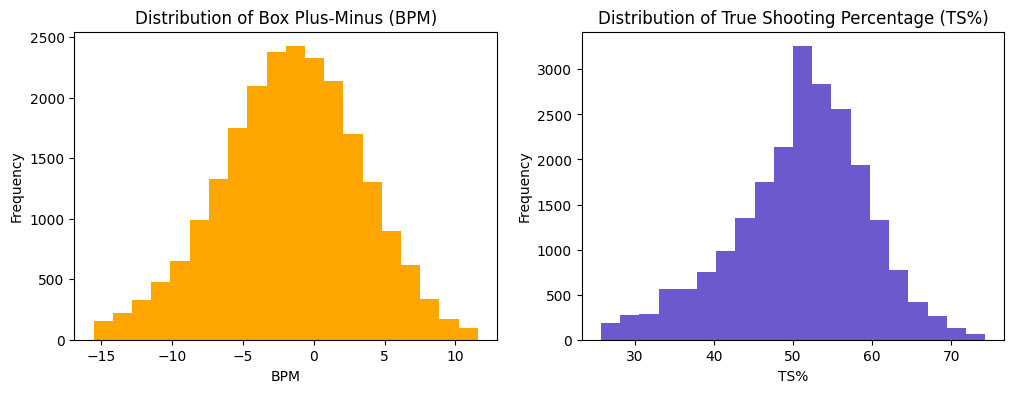

In [67]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

ax[0].hist(cleaned_df["bpm"], bins=20, color="orange")
ax[0].set_title('Distribution of Box Plus-Minus (BPM)')
ax[0].set_xlabel('BPM')
ax[0].set_ylabel('Frequency')

ax[1].hist(cleaned_df["TS_per"], bins=20, color="slateblue")
ax[1].set_title('Distribution of True Shooting Percentage (TS%)')
ax[1].set_xlabel('TS%')
ax[1].set_ylabel('Frequency')

In [68]:
bpm_mean = cleaned_df["bpm"].mean()
bpm_std = cleaned_df["bpm"].std()
bpm_max = cleaned_df["bpm"].max()
bpm_min = cleaned_df["bpm"].min()
print(f"Box Plus-Minus Mean: {bpm_mean}")
print(f"Box Plus-Minus Standard Deviation: {bpm_std}")
print(f"Box Plus-Minus Max: {bpm_max}")
print(f"Box Plus-Minus Min: {bpm_min}")
print("\n")
ts_mean = cleaned_df["TS_per"].mean()
ts_std = cleaned_df["TS_per"].std()
ts_max = cleaned_df["TS_per"].max()
ts_min = cleaned_df["TS_per"].min()
print(f"True Shooting Percentage Mean: {ts_mean}")
print(f"True Shooting Percentage Standard Deviation: {ts_std}")
print(f"True Shooting Percentage Max: {ts_max}")
print(f"True Shooting Percentage Min: {ts_min}")

Box Plus-Minus Mean: -1.6431692375983566
Box Plus-Minus Standard Deviation: 4.949175769085231
Box Plus-Minus Max: 11.588
Box Plus-Minus Min: -15.5376


True Shooting Percentage Mean: 50.91415665609789
True Shooting Percentage Standard Deviation: 8.489367952569943
True Shooting Percentage Max: 74.28
True Shooting Percentage Min: 25.7


##### Figure 2
The two bar charts show the distribution of players by year in college and draft status.
The year distribution indicates that the largest group of players in the dataset are fourth-year (senior) players, followed by third-year and second-year players, while first-year players make up the smallest group. This suggests that many players remain in college for several years before entering the draft or finishing their collegiate careers.

The draft status distribution shows a strong class imbalance, where the vast majority of players in the dataset were not drafted, while only a small fraction were selected in the NBA draft. Through further analysis, we see that the draft rate of players in the dataset is 2.7%, which is very low. This pattern is expected because the NBA draft selects a limited number of players each year compared to the large number of collegiate athletes. This imbalance is important to consider in later analysis, as it highlights how selective the draft process is and reinforces the need to identify performance characteristics that distinguish drafted players from the larger pool of undrafted players.


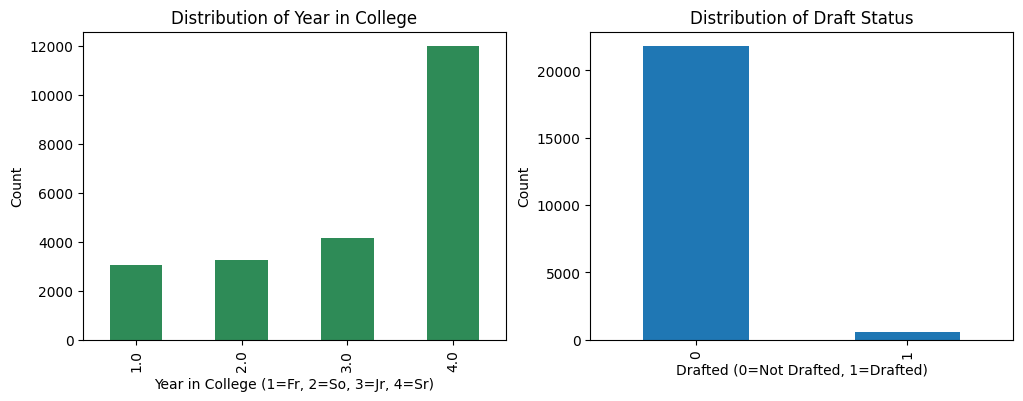

In [70]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

cleaned_df["yr_numerical"].value_counts().sort_index().plot(kind="bar", ax=ax[0], color="seagreen")
ax[0].set_title("Distribution of Year in College")
ax[0].set_xlabel("Year in College (1=Fr, 2=So, 3=Jr, 4=Sr)")
ax[0].set_ylabel("Count")

cleaned_df["drafted"].value_counts().sort_index().plot(kind="bar", ax=ax[1])
ax[1].set_title("Distribution of Draft Status")
ax[1].set_xlabel("Drafted (0=Not Drafted, 1=Drafted)")
ax[1].set_ylabel("Count")

plt.show()

In [71]:
draft_rate = cleaned_df["drafted"].mean()
print(f"The draft rate of players in the data set is: {np.round(draft_rate * 100, 2)}%")

The draft rate of players in the data set is: 2.7%


##### Figure 3
The bar chart shows the top 10 conferences represented in the dataset by number of players. Conferences such as MEAC, SWAC, and the Southland contain the largest number of players in the dataset, while conferences like the MAC and A-10 appear slightly less frequently among the top ten. The average player count per conference across the dataset is about 622 while the average player count across the top 10 conferences is bout 844. This distribution reflects the broad representation of conferences across NCAA basketball programs included in the dataset.

Understanding conference representation is useful because different conferences may vary in competition level, exposure, and player development opportunities, which can influence a player's chances of being drafted. While this visualization does not directly measure draft success by conference, it provides important context about where the majority of players in the dataset come from and highlights the diversity of collegiate programs represented in the analysis. It will also be interesting later in our analysis to identify if the conferences with the highest player counts also have the highest draft rates.


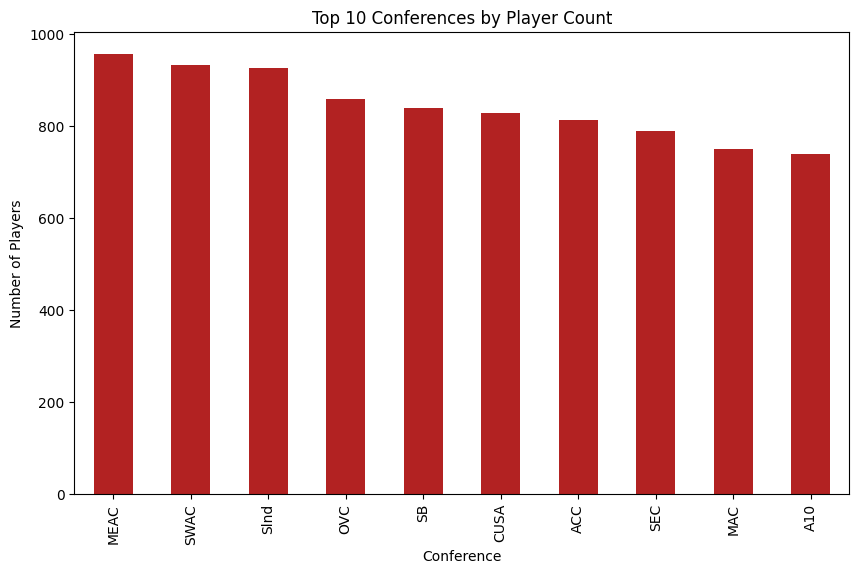

In [72]:
conf_player_counts = cleaned_df['conf'].value_counts()
top_conferences = conf_player_counts.head(10)

plt.figure(figsize=(10,6))
top_conferences.plot(kind='bar', color="firebrick")
plt.title('Top 10 Conferences by Player Count')
plt.xlabel('Conference')
plt.ylabel('Number of Players')

plt.show()

In [75]:
avg_conf_player_count = conf_player_counts.mean()
avg_top_conferences = top_conferences.mean()
print(f"Average Player Count per Conference: {np.round(avg_conf_player_count, 2)}")
print(f"Average Player Count for Top 10 Conferences: {np.round(avg_top_conferences, 2)}")

Average Player Count per Conference: 622.03
Average Player Count for Top 10 Conferences: 843.8


#### Section 2 of EDA if you need it  - Relationships Between Player Performance/Characteristics and Draft Outcomes

In this section, we examine how player performance and contextual factors relate to NBA draft outcomes. We begin by comparing True Shooting Percentage (TS%) and Box Plus-Minus (BPM) between drafted and undrafted players to investigate whether players selected in the NBA draft tend to demonstrate higher scoring efficiency and overall impact on the court. These metrics are widely used in basketball analytics and provide a useful way to evaluate player performance beyond traditional statistics.

Next, we explore the relationship between TS% and BPM using a scatter plot to observe how scoring efficiency and overall player impact interact across the dataset. We also analyze the draft rate by player year in college to understand how the likelihood of being drafted changes depending on how long a player remains in college. Finally, we examine draft rates across conferences to investigate whether players from certain conferences are drafted at higher rates than others. Together, these visualizations help identify patterns in performance, experience, and conference representation that may influence NBA draft selection.


##### Figure 1
The boxplots compare True Shooting Percentage (TS%) and Box Plus-Minus (BPM) between players who were drafted and those who were not. Drafted players tend to have higher median TS% values (57.3% > 51.4%), indicating that players selected in the NBA draft generally demonstrate greater scoring efficiency. While there is some overlap between the distributions, the overall shift toward higher TS% and smaller variation among drafted players suggests that efficient scorers may have a higher likelihood of being drafted.

A similar pattern is observed for Box Plus-Minus (BPM), where drafted players have significantly higher median values compared to undrafted players (6.8 > -1.7). Since BPM measures a player’s overall impact on team performance, this result suggests that players who contribute more positively across multiple aspects of the game are more likely to be selected in the draft. Together, these results indicate that both scoring efficiency and overall player impact may play an important role in NBA draft outcomes


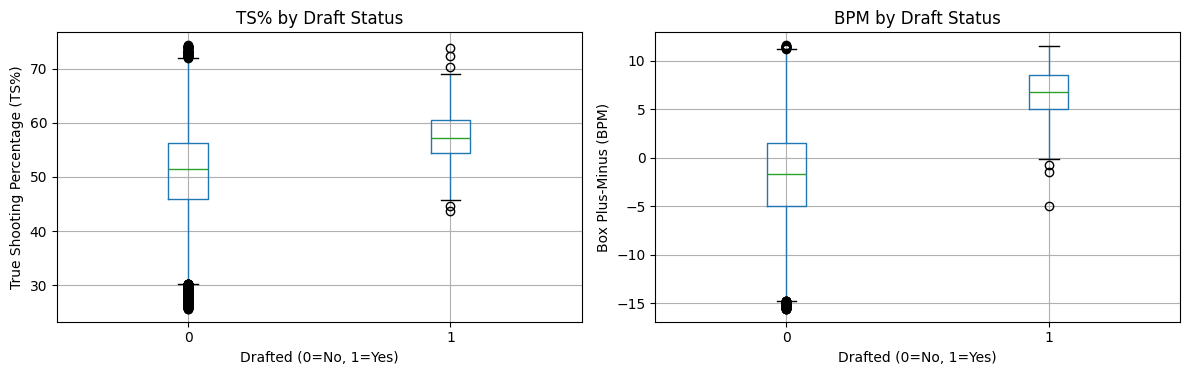

In [82]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

cleaned_df.boxplot(column="TS_per", by="drafted", ax=ax[0])
ax[0].set_title("TS% by Draft Status")
ax[0].set_xlabel("Drafted (0=No, 1=Yes)")
ax[0].set_ylabel("True Shooting Percentage (TS%)")

cleaned_df.boxplot(column="bpm", by="drafted", ax=ax[1])
ax[1].set_title("BPM by Draft Status")
ax[1].set_xlabel("Drafted (0=No, 1=Yes)")
ax[1].set_ylabel("Box Plus-Minus (BPM)")

plt.suptitle("")
plt.tight_layout()
plt.show()

In [84]:
not_drafted_ts_median = cleaned_df[cleaned_df["drafted"] == 0]["TS_per"].median()
drafted_ts_median = cleaned_df[cleaned_df["drafted"] == 1]["TS_per"].median()

print(f"The median TS% for non-drafted players is: {not_drafted_ts_median}%")
print(f"The median TS% for drafted players is: {drafted_ts_median}%")
print("")

not_drafted_bpm_median = cleaned_df[cleaned_df["drafted"] == 0]["bpm"].median()
drafted_bpm_median = cleaned_df[cleaned_df["drafted"] == 1]["bpm"].median()

print(f"The median bpm for non-drafted players is: {not_drafted_bpm_median}")
print(f"The median bpm for drafted players is: {drafted_bpm_median}")

The median TS% for non-drafted players is: 51.43%
The median TS% for drafted players is: 57.275%

The median bpm for non-drafted players is: -1.67831
The median bpm for drafted players is: 6.80722


##### Figure 2
The scatter plot shows the relationship between True Shooting Percentage (TS%) and Box Plus-Minus (BPM), with points colored by draft status. The linear regression line shows a positive relationship can be observed (R=0.56), where players with higher TS% values tend to also have higher BPM values. This suggests that players who score more efficiently often contribute more positively to their team's overall performance.

Additionally, drafted players tend to appear more frequently in the upper-right region of the plot, where both TS% and BPM are relatively high. This indicates that players who demonstrate both strong scoring efficiency and strong overall impact are more likely to be selected in the NBA draft. While there is still overlap between drafted and undrafted players, the clustering pattern suggests that stronger performance across multiple advanced metrics may increase a player's chances of being drafted.


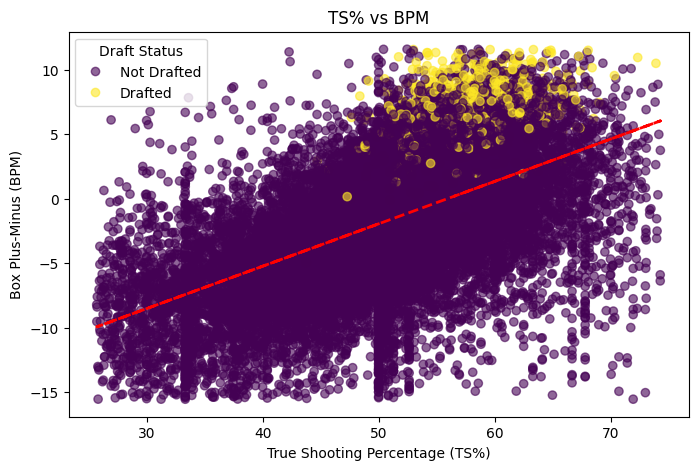

In [90]:
plt.figure(figsize=(8, 5))
scatter = plt.scatter(
    cleaned_df["TS_per"],
    cleaned_df["bpm"],
    c=cleaned_df["drafted"],
    alpha=0.6
)
#Best fit line
m, b = np.polyfit(cleaned_df["TS_per"], cleaned_df["bpm"], 1)
plt.plot(cleaned_df["TS_per"], m*cleaned_df["TS_per"] + b, color='red', linestyle='--', linewidth=2, label='Best Fit Line')


handles, labels = scatter.legend_elements()
plt.legend(handles=handles, labels=["Not Drafted", "Drafted"], title="Draft Status")
plt.title("TS% vs BPM")
plt.xlabel("True Shooting Percentage (TS%)")
plt.ylabel("Box Plus-Minus (BPM)")

plt.show()

In [91]:
corr = cleaned_df["bpm"].corr(cleaned_df["TS_per"])
print(f"The correlation between BPM and TS% is {np.round(corr, 2)}")

The correlation between BPM and TS% is 0.56


##### Figure 3
The bar chart shows the draft rate by player year in college, measured as the proportion of players from each class who were selected in the NBA draft. First-year players have the highest draft rate, followed by second-year players, while third- and fourth-year players have noticeably lower draft rates. This pattern reflects a common trend in college basketball where highly talented players often declare for the NBA draft earlier in their college careers.

The decreasing draft rate across later college years suggests that players who remain in college longer are statistically less likely to be selected in the draft. This may occur because many elite prospects enter the draft earlier once they demonstrate strong performance at the collegiate level. As a result, earlier-year players in the dataset tend to have a higher probability of being drafted compared to players who stay in school for four years.


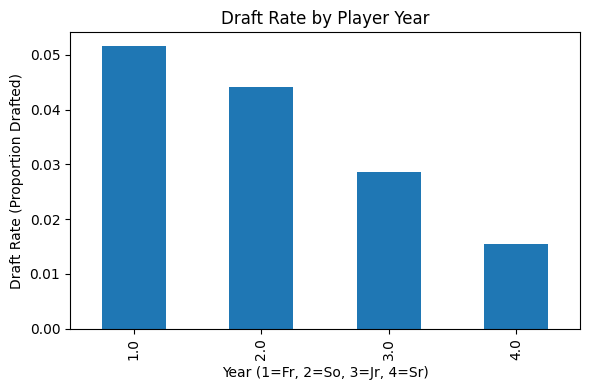

In [92]:
draft_rate_by_year = cleaned_df.groupby("yr_numerical")["drafted"].mean()

plt.figure(figsize=(6, 4))
draft_rate_by_year.plot(kind="bar")
plt.title("Draft Rate by Player Year")
plt.xlabel("Year (1=Fr, 2=So, 3=Jr, 4=Sr)")
plt.ylabel("Draft Rate (Proportion Drafted)")
plt.tight_layout()
plt.show()

##### Figure 4
The bar chart shows the top 10 conferences ranked by draft rate, measured as the proportion of players from each conference who were selected in the NBA draft. Conferences such as the ACC, Pac-10 (P10), and SEC have the highest draft rates, indicating that a larger share of players from these conferences are selected in the NBA draft compared to others.

An interesting analysis is that 25% of the conferences (9/36) have a draft rate higher than the draft rate of the total dataset. The median conference draft rate is 0.44% which is much lower than the dataset draft rate of 2.7%. This analysis shows that draft rate is very skewed between confereces, as the top few conferences have much higher draft rates than the rest of the conferences. This shows that there is a high chance that conference affiliation has an effect on a player's draft status.

This pattern likely reflects differences in competition level, player exposure, and program strength across conferences. Major conferences often feature stronger competition and receive greater national attention, which may increase opportunities for players to showcase their skills to NBA scouts. In contrast, conferences with lower draft rates may still produce talented players but have fewer athletes selected relative to the total number of players represented in the dataset.


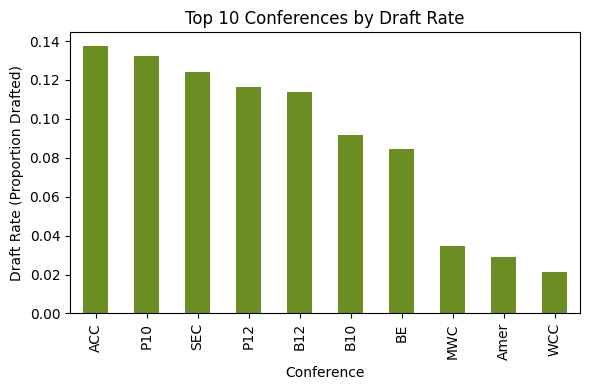

In [95]:
draft_rate_by_conf = cleaned_df.groupby("conf")["drafted"].mean().sort_values(ascending=False)

plt.figure(figsize=(6, 4))
draft_rate_by_conf.head(10).plot(kind="bar", color="olivedrab")
plt.title("Top 10 Conferences by Draft Rate")
plt.xlabel("Conference")
plt.ylabel("Draft Rate (Proportion Drafted)")
plt.tight_layout()
plt.show()

In [57]:
avg_draft_rate = cleaned_df['drafted'].mean()
print(f"{np.round(avg_draft_rate * 100, 2)}% of the players in the dataset were drafted to the NBA")

conf_above_draft_rate = draft_rate_by_conf >= avg_draft_rate
percentage_of_conf_above_draft_rate = conf_above_draft_rate.mean()
print(f"{np.round(percentage_of_conf_above_draft_rate * 100, 2)}% of the NCAA conferences have a draft rate higher than the draft rate of the dataset")

conf_median_draft_rate = draft_rate_by_conf.median()
print(f"The median draft rate of the conferences is {np.round(conf_median_draft_rate * 100, 2)}% which is well below the draft rate of the dataset")

2.7% of the players in the dataset were drafted to the NBA
25.0% of the NCAA conferences have a draft rate higher than the draft rate of the dataset
The median draft rate of the conferences is 0.44% which is well below the draft rate of the dataset


## Ethics

Ethics Checklist:

A. Data Collection

☐ A.1 Informed consent

 This project does not involve direct interaction with human subjects or the collection of original data. All data used consists of publicly available college basketball statistics and NBA draft records, which were collected by third-party organizations for public use. As a result, informed consent from individual subjects is not applicable in this context.

☒ A.2 Collection bias

 The data used in this project may reflect bias introduced during data collection because college basketball statistics and NBA draft outcomes are shaped by unequal media exposure, conference visibility, and scouting attention. Players from major conferences or high-profile programs may receive more attention than equally skilled players from smaller schools. This project acknowledges that draft outcomes are not a purely objective measure of ability and may reflect these existing biases.

☒ A.3 Limit PII exposure

 This project uses only publicly available data and does not include sensitive or private personal information. Player attributes such as height, age, and position are already public and directly relevant to the analysis. No unnecessary personally identifiable information is collected or displayed.

☒ A.4 Downstream bias mitigation

 Although the project does not use protected group labels, it recognizes that draft outcomes may reflect border systemic inequities. The analysis avoids treating draft selection as a measure of intrinsic player value and explicitly frames findings as exploratory associations rather than normative judgements.

B. Data Storage

☒ B.1 Data security

 All datasets will be stored locally or in private course repositories and used only for this class project. Since the data is public and non-sensitive, security risks are minimal, but basic precautions such as restricted access and avoiding unnecessary data sharing will still be followed.

☒ B.2 Right to be forgotten

There is no mechanism for individual data removal. All data originate from publicly archived sources that are outside the control of the research team. 

☒ B.3 Data retention plan

The datasets will be retained only for the duration of the academic project. No long-term reuse or redistribution of the compiled dataset is planned beyond course requirements. 

C. Analysis

☒ C.1 Missing perspectives

 This analysis focuses on quantitative performance metrics and does not capture qualitative factors such as leadership, work ethic, injury history, or scouting evaluations. These missing perspectives are acknowledged, and results will be interpreted with the understanding that statistics alone do not fully explain NBA draft decisions.

☒ C.2 Dataset bias

 NBA draft outcomes may embed historical and structural biases related to visibility, playing style preferences, or organizational decision-making. The analysis will avoid treating draft position as an objective ground truth and will frame results as associations rather than definitive evaluations of player quality.

☒ C.3 Honest representation

 Visualizations and summary statistics will be designed to accurately reflect the data without exaggerating trends or implying causation. Any limitations or weak relationships observed will be clearly reported rather than omitted.

☒ C.4 Privacy in analysis

 No private or sensitive personal information is used or displayed in the analysis beyond what is necessary to answer the research question.

☒ C.5 Auditability

 The analysis will be documented in a Jupyter notebook with clear explanations of data sources, cleaning steps, and analysis decisions so that results can be reproduced or reviewed if questions arise later.

D. Modeling

☒ D.1 Proxy discrimination

 This project does not intentionally include variables that serve as proxies for protected characteristics. However, it acknowledges that some variables, such as conference or school, could indirectly reflect broader inequalities, and results will be interpreted cautiously.

☐ D.2 Fairness across groups

 Formal fairness testing is not conducted because the project does not involve high-stakes decision-making or protected group labels. This limitation is explicitly acknowledged.

☒ D.3 Metric selection

 Any models or regressions used are intended for exploratory analysis rather than optimization or decision-making. Metrics are chosen to understand relationships, not to rank or judge individual players.

☒ D.4 Explainability

 All modeling approaches used in this project will be simple and interpretable, making it clear how variables relate to draft outcomes.

☒ D.5 Communicate limitations

 The limitations and assumptions of the analysis will be clearly stated so results are not misunderstood or overgeneralized.

E. Deployment

☐ E.1 Monitoring and evaluation

 This project does not deploy a model or system in a real-world setting, so ongoing monitoring is not applicable.

☐ E.2 Redress

 Because the analysis is not used to make real decisions about individuals, there is no formal redress mechanism.

☐ E.3 Roll back

 The project does not involve deployment, so rollback procedures are not relevant.

☒ E.4 Unintended use

 There is a risk that readers could overinterpret the results as definitive evaluations of player potential. To reduce this risk, the project explicitly frames findings as exploratory and contextual rather than prescriptive.


## Team Expectations 

- Team Expectation 1: Communication and Meetings

Our team will primarily communicate through messages for quick updates and questions, and we will use email for more formal communication if needed. We expect responses within 24 hours during the week unless someone communicates otherwise. The team will meet at least once per week, either in person or virtually, to check in on progress, discuss difficulties, and plan next steps.

- Team Expectation 2: Tone and Respectful Collaboration

We agree to communicate in a respectful, direct, and constructive manner. Feedback should be honest but polite, with the goal of improving the project rather than criticizing individuals.

- Team Expectation 3: Task Distribution and Accountability

Work will be divided so that responsibilities are shared evenly across the project, with each member contributing to multiple aspects such as data collection, analysis, coding, and writing. Tasks and deadlines will be clearly assigned and tracked in a shared document so everyone can see progress. If someone is struggling to complete a task, they are expected to communicate this early so the team can adjust or provide support.

- Team Expectation 4: Decision-Making Process

Most decisions will be made through group discussion and consensus when possible. If a decision needs to be made quickly and not all members are available, the members present will move forward and update the rest of the team afterward. For technical or section-specific decisions, responsibility may be delegated to the member leading that part of the project.

- Team Expectation 5: Handling Conflict and Team Issues

If conflicts or concerns arise, we will address them directly and respectfully as a group rather than letting issues build up. If a team member consistently does not meet agreed upon expectations, the group will first communicate concerns clearly and give the member an opportunity to improve. If issues continue, we will follow the course policy and reach out to the instructor as needed.

## Project Timeline Proposal

| Meeting Date  | Meeting Time| Completed Before Meeting  | Discuss at Meeting |
|---|---|---|---|
| Week 8  | TBD  | Continue analysis (correlations, regressions); draft results and discussion sections | Review analysis and interpretations; discuss limitations and ethical considerations |
| Week 9  | TBD  | Finalize analysis, visuals, and written sections; edit for clarity and consistency | Final review of full project; assign final edits and prepare for submission |
| Week 10  | TBD  | NA | Submit final notebook and complete group evaluations |